# R06 - Overhead

## Objetivo
Decompor o custo de orquestração da camada IBQN, independente do custo
da simulação SeQUeNCe, com dados reais da campanha final `F06_overhead`
(diamante, 3 condições x 20 seeds). Ver `docs/overhead_methodology.md` -
a instrumentação define 12 campos de tempo, 10 observáveis no caminho
atual (nunca "12 medidas completas"). Não roda simulação - carrega
apenas dados persistidos.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from ibqn.experiments.aggregation import aggregate_records
from ibqn.experiments.export import save_figure, save_table

# Executed with cwd=notebooks/ regardless of this file's own subdirectory
# (tests/notebooks/test_notebooks.py's NotebookClient.execute(cwd=...)) -
# matches notebooks/article/A0*.ipynb's own convention, not a path
# relative to notebooks/article/final/ itself.
RESULTS_DIR = Path("../results")

# A dedicated subdirectory, not results/figures/final/ directly: that
# directory's *.pdf/*.png are the curated, audited figure set
# (scripts/generate_final_figures.py + sources.json, checked by
# scripts/audit_final_results.py) - a notebook's own reproducibility
# export must not silently add uncatalogued files there.
FIGURES_OUT = RESULTS_DIR / "figures" / "final" / "from_notebooks"
TABLES_OUT = RESULTS_DIR / "tables" / "final"


## Carregar dados e verificar consistência

In [2]:
CAMPAIGN = "F06_overhead"
trials_df = pd.read_csv(RESULTS_DIR / "raw" / CAMPAIGN / "trials.csv")
manifest = json.load(open(RESULTS_DIR / "manifests" / f"{CAMPAIGN}.json", encoding="utf-8"))

assert len(trials_df) == manifest["completed_trials"] == 60
conditions = sorted(trials_df["condition"].unique())
assert conditions == ["ibqn_instrumented", "native_sequence", "static_provisioning"]
trials_df.head(3)

,condition,seed,intent_parsing_wall_time_s,intent_validation_wall_time_s,capability_extraction_wall_time_s,planning_wall_time_s,deployment_wall_time_s,assurance_wall_time_s,reconciliation_decision_wall_time_s,simulation_wall_time_s,total_orchestration_wall_time_s,total_trial_wall_time_s,orchestration_overhead_ratio,planning_overhead_ratio
0,ibqn_instrumented,0,0.0,0.0,0.000695,0.002275,0.001561,0.006765,0.001882,7.271347,0.013177,7.284524,0.001809,0.000312
1,native_sequence,0,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,17.781959,NaN,17.793131,0.000628,0.000000
2,static_provisioning,0,NaN,NaN,NaN,0.000381,NaN,NaN,NaN,7.218883,NaN,7.239712,0.002877,0.000053


## Overhead ratio: n, média, desvio, distribuição (nunca só a média)

In [3]:
summary = trials_df.groupby("condition")["orchestration_overhead_ratio"].agg(["count", "mean", "std", "min", "max"])
summary["mean_pct"] = summary["mean"] * 100
save_table(summary.reset_index(), "R06_overhead_ratio_summary", directory=TABLES_OUT)
print("max observed overhead ratio (any condition):", (trials_df["orchestration_overhead_ratio"].max() * 100).round(3), "%")
summary

max observed overhead ratio (any condition): 0.488 %


,count,mean,std,min,max,mean_pct
condition,,,,,,
ibqn_instrumented,20,0.001479,0.000294,0.001146,0.002387,0.147902
native_sequence,20,0.000584,0.000143,0.000313,0.000897,0.058417
static_provisioning,20,0.003028,0.000608,0.002419,0.004879,0.302753


## Figura: distribuição do overhead ratio (não apenas a média)

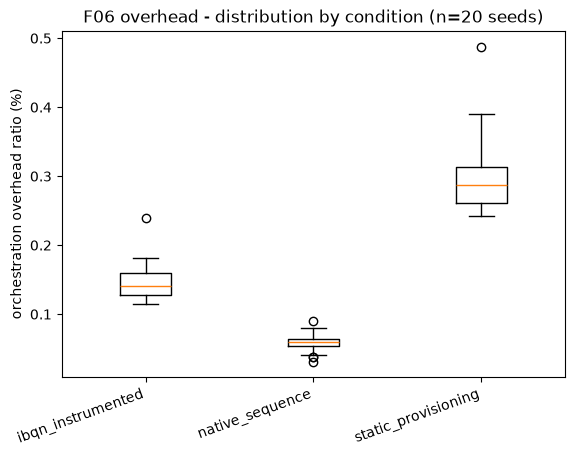

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
groups = [trials_df[trials_df["condition"] == c]["orchestration_overhead_ratio"].dropna() * 100 for c in conditions]
ax.boxplot(groups, tick_labels=conditions, showfliers=True)
ax.set_ylabel("orchestration overhead ratio (%)")
ax.set_title(f"F06 overhead - distribution by condition (n={trials_df['seed'].nunique()} seeds)")
plt.xticks(rotation=20, ha="right")
save_figure(fig, "R06_overhead_ratio_distribution", directory=FIGURES_OUT)
plt.show()

## Conclusão

O overhead médio de orquestração fica abaixo de 0.31% do tempo total de
trial nas condições avaliadas (nunca "desprezível" sem esse escopo -
`docs/overhead_methodology.md`). Achado adicional: `native_sequence`
leva ~2.5x mais tempo de SIMULAÇÃO (não de orquestração) que as outras
condições, porque processa muito mais eventos de entrelaçamento por
unidade de tempo simulado.

## Limitações

Medições de wall-clock são inerentemente ruidosas (contenção de CPU, coleta de lixo) - ordens de grandeza relativas, não valores absolutos precisos (ver `docs/overhead_methodology.md`).